# 深層生成モデル
**ベルヌーイ分布** を用いてMNISTデータセットをモデリングする.

また, 人工データを用いて **多次元ガウス分布** のモデリングを実装する.

In [1]:
# 必要なライブラリのインストール
import numpy as np
import matplotlib.pyplot as plt
import random # 追加: ランダムモジュールのインポート
import copy # 追加: copyモジュールのインポート
from keras.datasets import mnist # MNISTデータセットのインポート
import seaborn as sns # 追加: seabornのインポート
import math # 追加: mathモジュールのインポート
from scipy import stats # 追加: scipy.statsのインポート
# Jupyter Notebookでのインライン表示
%matplotlib inline

In [ ]:
# ヘルパー関数の定義
# 指定したラベルのインデックスを取得する関数
def get_label_idxs(labels: list, t_mnist: np.ndarray) -> np.ndarray:
    # 長さ60000のt_mnistについて，値が指定したラベルのうちのいずれかであるかのboolean arrayを取ってくる
    label_bool = np.any([t_mnist==label for label in labels], axis=0) # 60000*len(labels)のarray
    # Trueである要素のインデックスを得る
    label_idxs = np.where(label_bool)[0] # タプルの先頭要素の取り出し

    return label_idxs


# データの前処理を行う関数
def transforms(data_all: np.ndarray, flatten=True, binarize=True) -> np.ndarray:
    # 範囲を0~255から0~1にし，平坦化したあと，閾値0.5で0,1のバイナリにする
    data_all = data_all.astype(np.float64) / 255
    if flatten:
        data_all = data_all.reshape((data_all.shape[0], -1))
    if binarize:
        data_all = (data_all > 0.5).astype(np.uint8)

    return data_all

### 1. ベルヌーイ分布によるMNIST画像モデリング

MNIST画像の1種類のラベルのみを,単純な多次元ベルヌーイ分布でモデリングする.

In [ ]:
# ラベルが1のサンプルのみを600枚取ってくる
NUM_SAMPLES = 600

(x_mnist,t_mnist),_ = mnist.load_data() #　MNISTデータセットの学習画像の読み込み
print(f"x_mnist: {x_mnist.shape}, t_mnist: {t_mnist.shape}")

labels = [1]

label_idxs = get_label_idxs(labels, t_mnist)

data_all = x_mnist[label_idxs][:NUM_SAMPLES]
print(f"data_all: {data_all.shape}")

x_mnist: (60000, 28, 28), t_mnist: (60000,)
data_all: (600, 28, 28)


<Axes: >

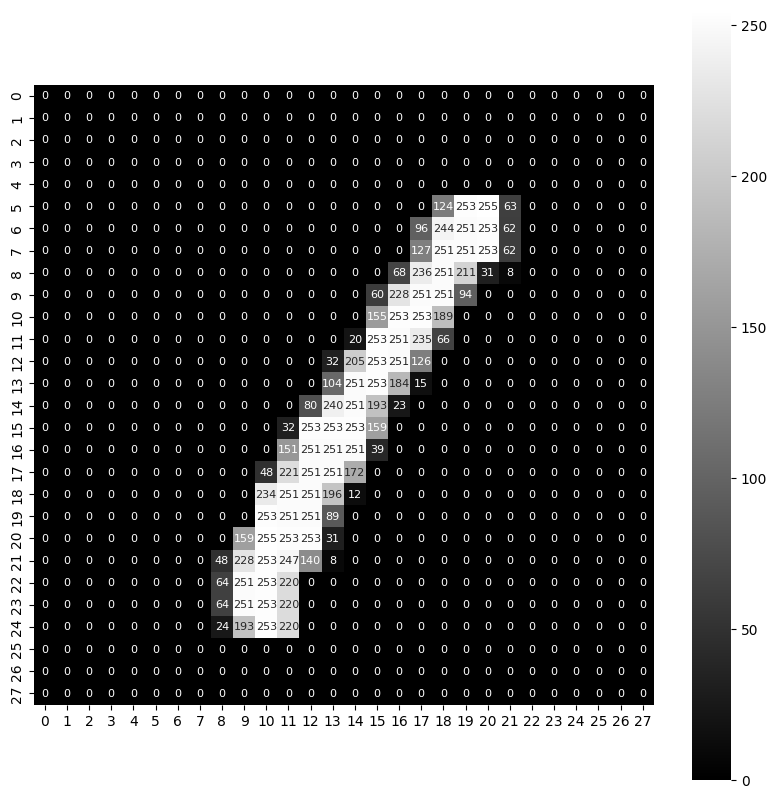

In [6]:
# 最初のサンプルを可視化してみる
plt.figure(figsize=(10, 10))
sns.heatmap(data_all[0], cmap='gray', annot=True, fmt='d', annot_kws={"fontsize":8}, square=True)

In [14]:
# 多次元ベルヌーイ分布によるモデリングのため,ピクセル値の0,1への二値化を行う
binary_data = transforms(data_all, flatten=True, binarize=True)
print(f"binary_data: {binary_data.shape}, unique values: {np.unique(binary_data)}")

binary_data: (600, 784), unique values: [0 1]


0の回数:  403
1の回数:  197


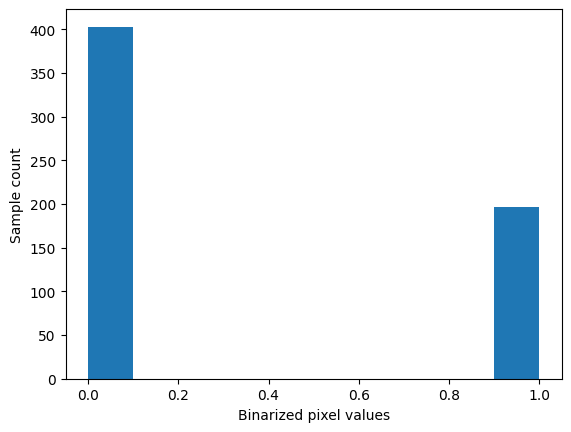

In [15]:
# あるピクセルについて, 値の分布をプロット
TARGET_PIXEL = 157

binary_pixel = binary_data[:, TARGET_PIXEL] # ( 600, )

print('0の回数: ', len(binary_pixel) - int(sum(binary_pixel)))
print('1の回数: ', int(sum(binary_pixel)))

plt.hist(binary_pixel)
plt.xlabel("Binarized pixel values")
plt.ylabel("Sample count")
plt.show()

各ピクセルそれぞれに個別のパラメータを持ったベルヌーイ分布が存在すると考えるので，ここでは一つのピクセルについてのみ記述(つまり$D=784$のインデックスを表す$d$を省略)．

観測データ集合を$X=\left\{x_{i}\right\}_{i=1}^{N}$とします($N=600$)．$x_{i}$は$i$枚目の画像のあるピクセルの値を，閾値0.5で0, 1に2値化したものです．

生成モデルの分布としてパラメータが$\mu$のベルヌーイ分布を考え，モデルを設計します．

$$
p_{\mu}({\bf x})=\prod_{i=1}^{N} \mu^{x_{i}}(1-\mu)^{1-x_{i}}
$$

$\mu$の推定量$\hat{\mu}$を最尤推定で求めます．

$$
\hat{\mu}=\underset{\mu}{\operatorname{argmax}} \sum_{i=1}^{N}\left[x_{i} \log \mu+\left(1-x_{i}\right) \log (1-\mu)\right]
$$

対数尤度関数を$\mu$について偏微分してゼロとおくことで，最尤推定量は次のように求まります．

$$
\hat{\mu}=\frac{1}{N}\sum_{i=1}^{N} x_{i}
$$

mu_hats: (784,), unique values: [0.         0.00166667 0.00333333 0.005      0.00666667 0.00833333
 0.01       0.01166667 0.01333333 0.015      0.01666667 0.01833333
 0.02       0.02166667 0.02333333 0.02666667 0.02833333 0.03
 0.03166667 0.035      0.03666667 0.03833333 0.04       0.04333333
 0.045      0.04833333 0.05166667 0.05333333 0.055      0.05833333
 0.06833333 0.075      0.07833333 0.08333333 0.085      0.08666667
 0.08833333 0.09       0.09333333 0.09666667 0.09833333 0.10166667
 0.10333333 0.105      0.10666667 0.11       0.11166667 0.11333333
 0.115      0.11833333 0.12       0.13       0.13166667 0.13833333
 0.14       0.145      0.15       0.15833333 0.16166667 0.17333333
 0.17666667 0.19166667 0.195      0.2        0.205      0.20833333
 0.21166667 0.22       0.23166667 0.24166667 0.26166667 0.265
 0.26666667 0.26833333 0.27166667 0.27333333 0.28666667 0.28833333
 0.29       0.29166667 0.29833333 0.30333333 0.305      0.30666667
 0.31166667 0.31666667 0.32       0.32333

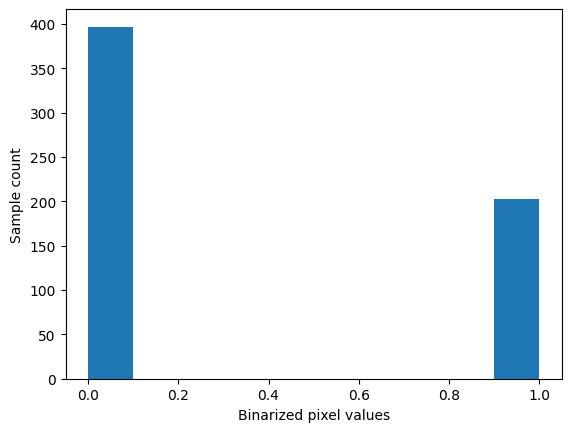

mu_hats: (784,)


In [ ]:
# 最尤推定
mu_hats = np.mean(binary_data, axis=0) # ( 784, )　# 各ピクセルが1である確率の推定値のベクトル
print(f"mu_hats: {mu_hats.shape}, unique values: {np.unique(mu_hats)}")

# TARGET_PIXELのmu_hatをパラメータとして, 生成するサンプル数を指定
sampled_data = stats.bernoulli.rvs(p=mu_hats[TARGET_PIXEL], size=NUM_SAMPLES)
print('0の回数: ', len(sampled_data) - sum(sampled_data))
print('1の回数: ', sum(sampled_data))

plt.hist(sampled_data)
plt.xlabel("Binarized pixel values")
plt.ylabel("Sample count")
plt.show()
print(f'mu_hats: {mu_hats.shape}') # ( 784, )

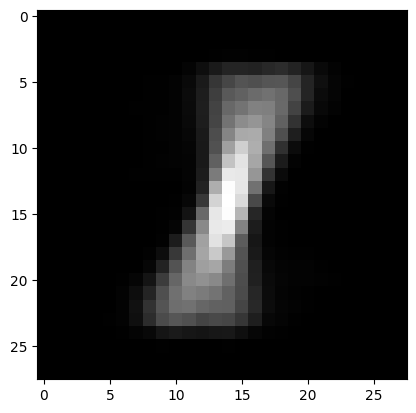

In [ ]:
# mu_hatsを画像として表示してみる
plt.imshow(mu_hats.reshape(28, 28), cmap='gray')

data_all: (1200, 28, 28)
binary_data: (1200, 784), set [0 1]
mu_hats: (784,)


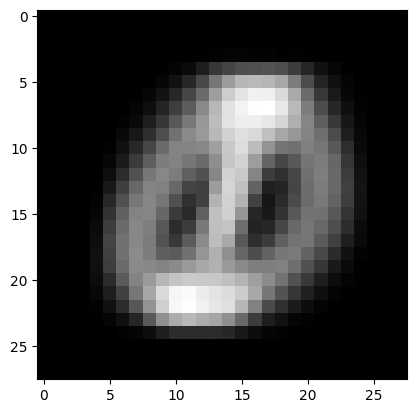

In [21]:
# ラベルが0のサンプルと混ぜる
NUM_SAMPLES = 1200

labels = [0, 1]

label_idxs = get_label_idxs(labels, t_mnist)
data_all = x_mnist[label_idxs][:NUM_SAMPLES]
print(f"data_all: {data_all.shape}")

binary_data = transforms(data_all)
print(f"binary_data: {binary_data.shape}, set {np.unique(binary_data)}")

# 最尤推定
mu_hats = np.mean(binary_data, axis=0) # ( 784, )
print(f'mu_hats: {mu_hats.shape}')

plt.imshow(mu_hats.reshape(28, 28), cmap="gray")

データのソースに明らかに複数の確率分布が考えられる場合は，潜在変数を考慮することが有用.

### 2. 多次元ガウス分布による人工データモデリング

In [22]:
# 真の分布（データ分布）として単一のガウス分布を定義
#（以下のパラメータは真の分布のパラメータなので，推定（学習）時にはわからないことに注意）
_mu = np.array([0, 0])  # 平均
_sigma = np.array([[1.0, 0.5], [0.5, 1.0]])  # 共分散行列

NUM_DATA = 3000

# ガウス分布からサンプリング（訓練データ）
data_all = np.random.multivariate_normal(_mu, _sigma, NUM_DATA)

print(f"data_all: {data_all.shape}")

data_all: (3000, 2)


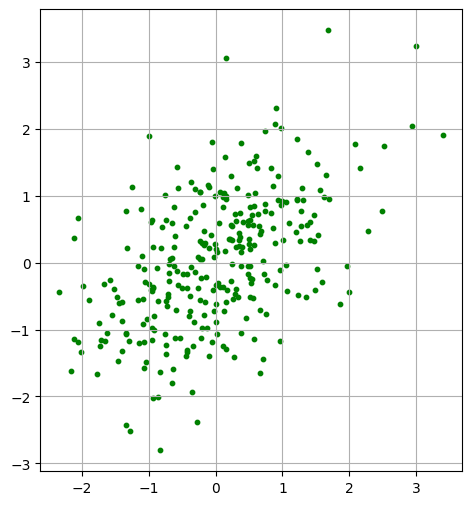

In [29]:
#データ点の可視化
NUM_SAMPLES = 300

x = np.arange(-5, 5, 0.05) # x軸
y = np.arange(-5, 5, 0.05) # y軸

fig, ax = plt.subplots(figsize=(8.0, 6.0))
plt.scatter(data_all[:NUM_SAMPLES, 0], data_all[:NUM_SAMPLES, 1], s=10, c='g')
ax.set_aspect('equal','box')
plt.grid(True)
plt.show()

生成モデルの分布として,パラメータが $\boldsymbol{\mu}$（平均ベクトル）と $\boldsymbol{\Sigma}$（共分散行列）の **多次元ガウス分布** を考え，モデルを設計します．

$$
p_{\boldsymbol{\mu}, \boldsymbol{\Sigma}}(\mathbf{x}) = \frac{1}{(2\pi)^{d/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)
$$

$\boldsymbol{\mu}$ の推定量 $\hat{\boldsymbol{\mu}}$ と $\boldsymbol{\Sigma}$ の推定量 $\hat{\boldsymbol{\Sigma}}$ を 最尤推定で求めます．

対数尤度関数は次のようになります．

$$
\log p_{\boldsymbol{\mu}, \boldsymbol{\Sigma}}(\mathbf{X}) = -\frac{N d}{2} \log(2\pi) - \frac{N}{2} \log |\boldsymbol{\Sigma}| - \frac{1}{2} \sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})
$$

この式を $\boldsymbol{\mu}$ と $\boldsymbol{\Sigma}$ について偏微分し，ゼロとおくことで最尤推定量が求まります．

- 平均ベクトルの最尤推定量:

$$
\hat{\boldsymbol{\mu}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i
$$

- 共分散行列の最尤推定量:

$$
\hat{\boldsymbol{\Sigma}} = \frac{1}{N} \sum_{i=1}^{N} (\mathbf{x}_i - \hat{\boldsymbol{\mu}})(\mathbf{x}_i - \hat{\boldsymbol{\mu}})^T
$$

この結果より，最尤推定では データの平均と共分散 を計算することで，ガウス分布のパラメータを推定できることが分かります．

In [25]:
# データの平均と共分散を求める関数
def estimate_gaussian_params(data_all):
    mu = np.mean(data_all, axis=0)  # 平均
    sigma = np.cov(data_all, rowvar=False)  # 共分散行列
    return mu, sigma

# 単一のガウス分布を推定
mu_hats, sigma_hats = estimate_gaussian_params(data_all)

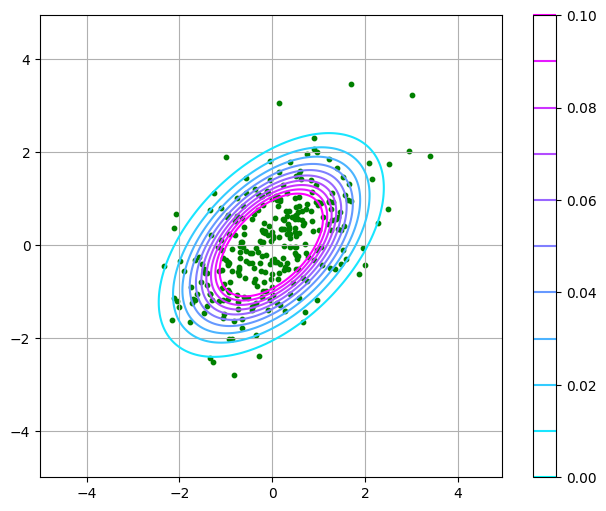

In [26]:
# 推定したパラメータに基づくガウス分布の可視化

# 共分散行列の逆行列と行列式
sigma_hats_inv = np.linalg.inv(sigma_hats)
sigma_hats_det = np.linalg.det(sigma_hats)

# メッシュグリッドの作成
x = np.arange(-5, 5, 0.05)  # x軸
y = np.arange(-5, 5, 0.05)  # y軸
X, Y = np.meshgrid(x, y)  # (200, 200)

# ガウス密度関数
def gaussian_density(x, mu, sigma_inv, sigma_det):
    diff = x - mu
    exponent = -0.5 * diff.T @ sigma_inv @ diff
    return np.exp(exponent) / (2 * np.pi * np.sqrt(sigma_det))

# 密度の計算
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(Y.shape[1]):
        Z[i, j] = gaussian_density(np.array([X[i, j], Y[i, j]]), mu_hats, sigma_hats_inv, sigma_hats_det)

# データ点の可視化
fig, ax = plt.subplots(figsize=(8.0, 6.0))
data_plot = plt.scatter(data_all[:NUM_SAMPLES, 0], data_all[:NUM_SAMPLES, 1], s=10, c='g')
contour = ax.contour(X, Y, Z, levels=[0.01 * i for i in range(11)], cmap='cool')
plt.colorbar(contour)
ax.set_aspect('equal', 'box')
plt.grid(True)
plt.show()

また推定したガウス分布は生成モデルなので，元のデータと類似した新しいデータ点を生成することもできます．

In [27]:
# 新しいデータの生成
NUM_GENERATED = 100
new_data = np.random.multivariate_normal(mu_hats, sigma_hats, NUM_GENERATED)

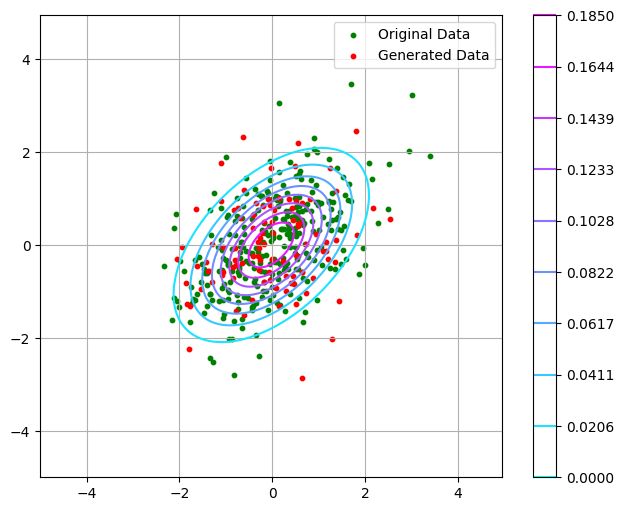

In [28]:
# データ点の可視化
fig, ax = plt.subplots(figsize=(8.0, 6.0))
data_plot = plt.scatter(data_all[:NUM_SAMPLES, 0], data_all[:NUM_SAMPLES, 1], s=10, c='g', label='Original Data')
generated_plot = plt.scatter(new_data[:, 0], new_data[:, 1], s=10, c='r', label='Generated Data')
contour = ax.contour(X, Y, Z, levels=np.linspace(Z.min(), Z.max(), 10), cmap='cool')
plt.colorbar(contour)
ax.set_aspect('equal', 'box')
plt.legend()
plt.grid(True)
plt.show()